In [ ]:
import torch
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader,TensorDataset

fashion_train = pd.read_csv("./data/fashion-mnist_train.csv")
fashion_test = pd.read_csv("./data/fashion-mnist_test.csv")

In [ ]:
x_train = torch.tensor(fashion_train.drop(columns=["label"]).values.reshape(-1, 1, 28, 28)).float()
y_train = torch.tensor(fashion_train["label"]).long()
x_test = torch.tensor(fashion_test.drop(columns=["label"]).values.reshape(-1, 1, 28, 28)).float()
y_test = torch.tensor(fashion_test["label"]).long()
train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)

In [13]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2),
    nn.Sigmoid(),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0),

    nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0),
    nn.Sigmoid(),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0),

    nn.Flatten(), 

    nn.Linear(400, 120),
    nn.Sigmoid(),

    nn.Linear(120, 84),
    nn.Sigmoid(),

    nn.Linear(84, 10),
)

In [28]:
def train(model, train_dataset, test_dataset, lr, epochs, batch_size, device):
    def init_weights(layer):
        if isinstance(layer, nn.Linear) or isinstance(layer, nn.Conv2d):
            nn.init.xavier_uniform_(layer.weight)

    model.apply(init_weights)
    model.to(device)
    loss = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        train_loss = 0.0
        train_correct = 0
        for batch_idx, (x,y) in enumerate(dataloader):
            x = x.to(device)
            y = y.to(device)
            output = model(x)
            loss_value = loss(output, y) 
            loss_value.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_loss += loss_value.item() * x.shape[0] # 累计批次损失
            pred = output.argmax(dim=1) # 取批次预测类别
            train_correct += (pred == y).sum().item() # 累计批次正确预测数量

            print(f"\r Epoch: {epoch+1:0>2} [{'=' * int((batch_idx+1) / len(dataloader)*50) }]", end="")
        this_loss = train_loss / len(train_dataset) # 本轮损失
        train_acc = train_correct / len(train_dataset) # 本轮准确率
        
        model.eval()
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        test_correct = 0
        with torch.no_grad():
            for x,y in test_loader:
                x = x.to(device)
                y = y.to(device)
                output = model(x)
                pred = output.argmax(dim=1) # 取批次预测类别
                test_correct += (pred == y).sum().item() # 累计批次正确预测数量
        this_test_acc = test_correct / len(test_dataset) # 本轮测试准确率

        print(f"train_loss: {this_loss:.4f}, train_acc: {train_acc:.4f}, test_acc: {this_test_acc:.4f}")

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lr = 0.01
epochs = 20
batch_size = 256

train(model, train_dataset, test_dataset, lr, epochs, batch_size, device)

 Epoch: 01 [==================================================]train_loss: 0.8854, train_acc: 0.6673, test_acc: 0.8287
 Epoch: 02 [==================================================]train_loss: 0.4370, train_acc: 0.8371, test_acc: 0.8489
 Epoch: 03 [==================================================]train_loss: 0.3732, train_acc: 0.8604, test_acc: 0.8748
 Epoch: 04 [==================================================]train_loss: 0.3410, train_acc: 0.8730, test_acc: 0.8682
 Epoch: 05 [==================================================]train_loss: 0.3257, train_acc: 0.8773, test_acc: 0.8731
 Epoch: 06 [==================================================]train_loss: 0.3156, train_acc: 0.8810, test_acc: 0.8791
 Epoch: 07 [==================================================]train_loss: 0.3026, train_acc: 0.8863, test_acc: 0.8832
 Epoch: 08 [==================================================]train_loss: 0.2976, train_acc: 0.8871, test_acc: 0.8868
 Epoch: 09 [====================================

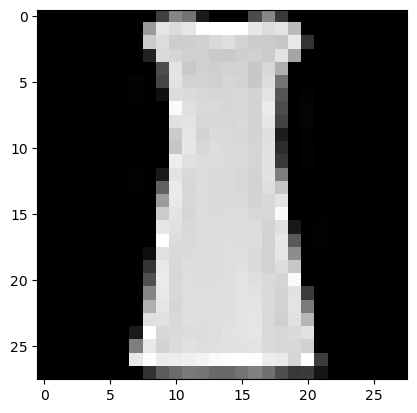

tensor(3)
tensor([3], device='cuda:0')


In [30]:
plt.imshow(x_test[99,0], cmap="gray" )
plt.show()
print(y_test[99] )

output = model(x_test[99].unsqueeze(0).to(device))
y_pred = output.argmax(dim=1)
print(y_pred)
